In [1]:
import os
import sys
import time
import copy
sys.path.append('~/SLM')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import numpy as np
import json
import math
import random
import matplotlib.pyplot as plt

from tokenizers import Tokenizer

import models, init, train, measures
import importlib
# Reload the modules
importlib.reload( models)

device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(device)

cuda


In [2]:
#Create a namespace object to hold the arguments 
class Namespace:
    def __init__(self, **kwargs):
        self.__dict__.update(kwargs)

args = {}
args['device'] = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'


# # TEST ON TINYSTORIES
args['dataset'] = "tinystories.BPE8192"
args['path'] = "datasets/tinystories/"
args['tokenizer'] = "tinystories.BPE8192.meta.json"

args['block_size'] = 128 # maximal context length
args['batch_size'] = 1
args['train_size'] = 2**20
args['val_size'] = 2**18
args['online'] = False
args['max_epochs'] = 8

# TEST ON RHM
# args['dataset'] = "rhm.L5s2v32m4.12345678"
# args['path'] = "datasets/rhm/"
# args['tokenizer'] = "rhm.L5s2v32m4.12345678.meta.json"

# args['block_size'] = 64 # maximal context length
# args['batch_size'] = 128
# args['train_size'] = 2**25
# args['val_size'] = 2**17

# MODEL ATTRIBUTES
# args['d_embedding'] = 512
# args['n_heads'] = 8
# args['ffwd_size'] = 4
# args['depth'] = 8
# args['rope'] = True
# args['dropout'] = 0.
# args['seed_model'] = 1234

# TRAINING ATTRIBUTES
# args['optim'] = 'adam'
# args['lr'] = 3e-4
# args['scheduler'] = 'cosine'
# args['warmup_time'] = 8
# args['decay_time'] = 2048
# args['decay_factor'] = 0.1
# args['l2'] = 0.
# args['max_epochs'] = 4

# SAVING ATTRIBUTES
# args['print_freq'] = 1024
# args['save_freq'] = 3
args['measure_train'] = False
args['loss_by_token'] = True

args['device'] = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

args = Namespace(**args)
print(args.device)

cuda


## LOAD dataset and INIT training and validation set

In [3]:
tokenizer, train_loader, val_loader = init.init_data(args)

# create extra training loader for computing loss over the whole training dataset
if args.measure_train:
    extrain_loader = copy.deepcopy(train_loader)

vocabulary size: 8192
number of training tokens: 529209187
loaded 1048577 tokens, split into 8192 batches
number of validation tokens: 5343921
loaded 262145 tokens, split into 2048 batches
Training for 65536 steps


## INIT causal language model from models

In [13]:
# GPT2
# args.model = 'gpt2'
# args.d_embedding = 256
# args.depth = 2

# args.n_heads = 4
# args.ffwd_size = 4
# args.rope = True

# args.dropout = 0.
# args.seed_model = 1234

# Mamba
args.model = 'mamba'
args.d_embedding = 256
args.depth = 4

args.d_state = 16
args.d_conv = 4
args.mamba_expand = 2

args.dropout = 0.
args.seed_model = 1234

model = init.init_model( args)
model0 = copy.deepcopy( model)

# parameters: 5946624


## INIT criterion, optimizer, scheduler

In [14]:
args.optim = 'adam'
args.lr = 3e-4
args.scheduler = 'cosine'
args.warmup_time = 8
args.decay_time = 2 * train_loader.num_batches
args.decay_factor = 0.1
args.l2 = 0.0
print(args.decay_time)

args.print_freq = 1024
args.save_freq = 3
args.measure_train = False
args.loss_by_token = True

criterion, optimizer, scheduler = init.init_training( model, args)

16384


In [15]:
%%time
dynamics = []
val_loss = measures.evaluate(model, criterion, val_loader, val_loader.num_batches, args.device)
dynamics.append({'t': 0, 'val_loss': val_loss})
if args.measure_train:
    train_loss = measures.evaluate(model, criterion, extrain_loader, extrain_loader.num_batches, args.device)
    dynamics[-1]['train_loss'] = train_loss
if args.loss_by_token:
    ngram_loss = measures.loss_by_token( model, criterion, val_loader, args.block_size, val_loader.num_batches, args.device)
    dynamics[-1]['ngram_loss'] = ngram_loss

print_ckpts, save_ckpts = init.init_loglinckpt( args.print_freq, args.max_steps, freq=args.save_freq)
print_ckpt = next(print_ckpts)
save_ckpt = next(save_ckpts)

print("Valid loss at init: ", val_loss, f"(compare with {math.log(args.vocab_size)})")

Valid loss at init:  9.155326071195304 (compare with 9.010913347279288)
CPU times: user 32.9 s, sys: 12 ms, total: 32.9 s
Wall time: 32.9 s


In [16]:
for step in range(args.max_steps):

    t0 = time.time()
    loss = train.train_step( model, train_loader, criterion, optimizer, scheduler, args.device)
    t1 = time.time()
    dt = (t1-t0)*1000

    if (step+1)==print_ckpt:

        val_loss = measures.evaluate(model, criterion, val_loader, val_loader.num_batches, args.device)
        print(f'step {step+1}, running loss {loss}, dt={dt:.2f}ms, validation loss {val_loss}')
        
        print_ckpt = next(print_ckpts)

        if (step+1)>=save_ckpt:

            print(f'Evaluating at {step+1} ...')
            dynamics.append({'t': step+1, 'val_loss': val_loss})
            if args.measure_train:
                train_loss = measures.evaluate(model, criterion, extrain_loader, extrain_loader.num_batches, args.device)
                dynamics[-1]['train_loss'] = train_loss
            if args.loss_by_token:
                ngram_loss = measures.loss_by_token( model, criterion, val_loader, args.block_size, val_loader.num_batches, args.device)
                dynamics[-1]['ngram_loss'] = ngram_loss

            save_ckpt = next(save_ckpts)

step 1, running loss 9.124726295471191, dt=44.46ms, validation loss 9.155326071195304
Evaluating at 1 ...
step 2, running loss 9.169219017028809, dt=30.48ms, validation loss 9.144725422840565
Evaluating at 2 ...
step 3, running loss 9.159122467041016, dt=29.01ms, validation loss 9.120920528192073
Evaluating at 3 ...
step 4, running loss 9.095564842224121, dt=29.05ms, validation loss 9.08566096238792
Evaluating at 4 ...
step 5, running loss 9.035605430603027, dt=29.03ms, validation loss 9.039081962313503
Evaluating at 5 ...
step 6, running loss 9.024740219116211, dt=29.14ms, validation loss 8.981664702761918
Evaluating at 6 ...
step 7, running loss 8.9755859375, dt=29.11ms, validation loss 8.914493209682405
Evaluating at 7 ...
step 8, running loss 8.775959968566895, dt=29.02ms, validation loss 8.833045905921608
Evaluating at 8 ...
step 10, running loss 8.78303050994873, dt=29.17ms, validation loss 8.6465904279612
Evaluating at 10 ...
step 13, running loss 8.338812828063965, dt=29.15ms, 

KeyboardInterrupt: 

## PLOT validation loss vs time

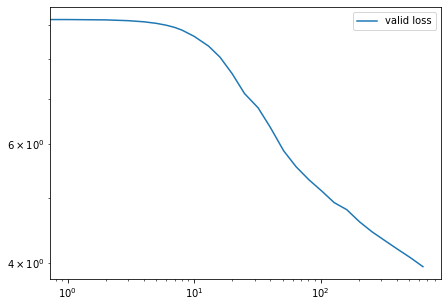

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))

ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C0', label='valid loss')
# ax.plot([d['t'] for d in dynamics], [d['train_loss'] for d in dynamics], f'C1', label='train loss')

ax.legend()
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

KeyError: 'ngram_loss'

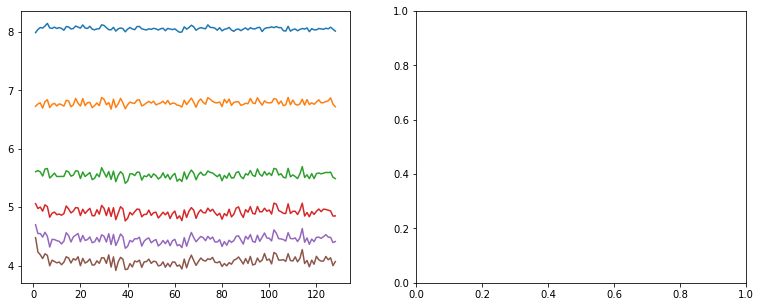

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(13,5))

for time in [16, 32, 64, 128, 256, 512]:

    selected = list(filter(lambda x: x['t'] == time, dynamics))
    result = selected[0]
    ax[0].plot(torch.arange(1,result['ngram_loss'].size(0)+1), result['ngram_loss'], label=f't={time}')


for n in [1,2,4,8,16,32,64]:


    ax[1].plot([d['t'] for d in dynamics], [d['ngram_loss'][n-1] for d in dynamics], label=f'n={n}')

ax[1].plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], 'k--', label='valid loss')


ax[0].legend()
# ax.set_xlim(1,16)
ax[0].set_xscale('log')
ax[0].set_xlabel(r'$n$', fontsize=15)
# ax.set_ylim(1.,5.)
ax[0].set_yscale('log')
ax[0].set_ylabel(r'$\mathcal{L}_n(t)$', fontsize=15)

ax[1].legend()
ax[1].set_xscale('log')
ax[1].set_xlabel(r'$t$', fontsize=15)

ax[1].set_yscale('log')
# ax[1].set_ylabel(r'$\mathcal{L}_n(t)$', fontsize=15)

## Generate sequences from trained model

In [20]:
# load tokenizer
tokenizer_file = tokenizer['tokenizer_file']
tokenizer = Tokenizer.from_file('datasets/'+tokenizer_file)

### Starting from 'Once upon a time, '

In [21]:
num_sequences = 16
tokens = tokenizer.encode("Once upon a time, ")
prompts = torch.tensor(tokens.ids, dtype=torch.long)
prompts = prompts.unsqueeze(0).repeat(num_sequences, 1).to(device) # size B, T
print(prompts.size())

model.eval()
with torch.no_grad():
    generated = model.generate(prompts, num_tokens=64)
print(generated.size())

for i in range(num_sequences):
    print(i)
    print(tokenizer.decode(generated[i].tolist()))
    print('\n')

torch.Size([16, 5])
torch.Size([16, 69])
0
Once upon a time , in left they knew a small , important pan anymore . Lily safe and ness the turtle where Tom asked . They wanted to eat . Tim said , " Wow , I have truly , I ' m better !" Tom said . " Maybe them you Later fence you Ah me come back back ." But then , a little girl


1
Once upon a time , there toys girl . They looked at the everything and aches ," Max are row . Sara behind her mom to touch the ally and played with each other . Once upon a time , there was a tummies . They played together glove down the cake to ¡ stay made leave ." Tom thought around and wanted to laughing . Tom said


2
Once upon a time , there was a small dog cat . Tom would . " Tammy Monster , Spot ." Lily always hard to to So . While she is little , but she was wide out to explore and it on it . Tim was wheel in the big tree . So , they who was tired . It was a puddle and knew that it was


3
Once upon a time , there was a Ruth , in a met small , there was 

### Starting from 'EOS'

In [ ]:
vocab = tokenizer.get_vocab()
print(vocab['<eos>'])

prompts = torch.tensor([vocab['<eos>']], dtype=torch.long)
prompts = prompts.unsqueeze(0).repeat(num_sequences, 1).to(device) # size B, T
print(prompts.size())

model.eval()
with torch.no_grad():
    generated = model.generate(prompts, num_tokens=64)
print(generated.size())

for i in range(num_sequences):
    print(i)
    print(tokenizer.decode(generated[i].tolist()))
    print('\n')


In [ ]:
print(args.__dict__)

output = {
    'model': copy.deepcopy(model.state_dict()),
    'dynamics': dynamics,
}
torch.save(
    {'config': args.__dict__, 'output': output},
    f"example_output.pt"
)